# Example usage of the ofset free koopman MPC

In [169]:
import sys
import os
import numpy as np
#import pandas as pd
import joblib
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
import torch
from sklearn.preprocessing import StandardScaler

from neuromancer.system import Node, System
from neuromancer.trainer import Trainer
from neuromancer.problem import Problem
from neuromancer.dataset import DictDataset
from neuromancer.constraint import variable
from neuromancer.loss import PenaltyLoss
from neuromancer. modules import blocks

# Add 'src' to Python path
project_root = os.path.abspath(os.path.join(os.getcwd(), '../..'))
src_path = os.path.join(project_root, 'src')
sys.path.append(src_path)

import models
import helper
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Loading a Dataset

## Preparing data for training koopman models

In [170]:
def get_data(train_sim, dev_sim, test_sim, nsteps, bs, scaler, scalerU):
    
    ny = train_sim['Y'].shape[1]
    nu = train_sim['U'].shape[1]
    
    nsim = train_sim['Y'].shape[0]
    nbatch = nsim//nsteps
    length = (nsim//nsteps) * nsteps

    trainX = scaler.transform(train_sim['Y'][:length])
    trainX = trainX.reshape(nbatch, nsteps, ny)
    trainX = torch.tensor(trainX, dtype=torch.float32)
    trainU = scalerU.transform(train_sim['U'][:length])
    trainU = trainU.reshape(nbatch, nsteps, nu)
    trainU = torch.tensor(trainU, dtype=torch.float32)
    train_data = DictDataset({'Y': trainX, 'Y0': trainX[:, 0:1, :],
                              'U': trainU}, name='train')
    train_loader = DataLoader(train_data, batch_size=bs,
                              collate_fn=train_data.collate_fn, shuffle=True)
    
    nsim = dev_sim['Y'].shape[0]
    nbatch = nsim//nsteps
    length = (nsim//nsteps) * nsteps
    
    devX = scaler.transform(dev_sim['Y'][:length])
    devX = devX.reshape(nbatch, nsteps, ny)
    devX = torch.tensor(devX, dtype=torch.float32)
    devU = scalerU.transform(dev_sim['U'][:length])
    devU = devU[:length].reshape(nbatch, nsteps, nu)
    devU = torch.tensor(devU, dtype=torch.float32)
    dev_data = DictDataset({'Y': devX, 'Y0': devX[:, 0:1, :],
                            'U': devU}, name='dev')
    dev_loader = DataLoader(dev_data, batch_size=bs,
                            collate_fn=dev_data.collate_fn, shuffle=True)

    nsim = test_sim['Y'].shape[0]
    nbatch = nsim//nsteps
    length = (nsim//nsteps) * nsteps
    
    testX = scaler.transform(test_sim['Y'][:length])
    testX = testX.reshape(1, nbatch*nsteps, ny)
    testX = torch.tensor(testX, dtype=torch.float32)
    testU = scalerU.transform(test_sim['U'][:length])
    testU = testU.reshape(1, nbatch*nsteps, nu)
    testU = torch.tensor(testU, dtype=torch.float32)
    test_data = {'Y': testX, 'Y0': testX[:, 0:1, :],
                 'U': testU}
    
    nsim = train_sim['Y'].shape[0]
    nbatch = nsim//nsteps
    length = (nsim//nsteps) * nsteps

    trainX = scaler.transform(train_sim['Y'][:length])
    trainX = trainX.reshape(1, nbatch*nsteps, ny)
    trainX = torch.tensor(trainX, dtype=torch.float32)
    trainU = scalerU.transform(train_sim['U'][:length])
    trainU = trainU.reshape(1, nbatch*nsteps, nu)
    trainU = torch.tensor(trainU, dtype=torch.float32)
    train_data_forC = {'Y': trainX, 'Y0': trainX[:, 0:1, :],
                 'U': trainU}

    return train_loader, dev_loader, test_data, train_data_forC

In [171]:
# Load identification data from ../ident_data/ (.mat files)
# After downsampling: Y = [T1, T2, T4, L], U = [u1, u2, u3].
# Any nsteps_training-length window where some L > L_max_ident is dropped entirely (keeps training windows clean).
from scipy.io import loadmat

data_path = '../ident_data/'

experiment_start = 0
experiment_end = 14  # inclusive; adjust to match available ident_data runs


def trim_to_divisible(arr, divisor=80):
    """Trim array from the rear to make length divisible by divisor"""
    length = len(arr)
    remainder = length % divisor
    if remainder != 0:
        return arr[:length - remainder]
    return arr


nsteps_training = 60  # Must match nsteps used in model training
L_max_ident = 100  # Drop whole windows (length nsteps_training) if any L in that window exceeds this
experiments = []

# Outputs: Y = [T1, T2, T4, L] with L = 10^[(T1-40)/5]. Inputs: u1, u2, u3.

for exp_num in range(experiment_start, experiment_end + 1):
    T1_data = loadmat(data_path + f'T1_ident_{exp_num}.mat')['T1']
    T2_data = loadmat(data_path + f'T2_ident_{exp_num}.mat')['T2']
    T4_data = loadmat(data_path + f'T4_ident_{exp_num}.mat')['T4']
    u1_data = loadmat(data_path + f'u1_ident_{exp_num}.mat')['u1'].reshape(-1, 1)
    u2_data = loadmat(data_path + f'u2_ident_{exp_num}.mat')['u2'].reshape(-1, 1)
    u3_data = loadmat(data_path + f'u3_ident_{exp_num}.mat')['u3'].reshape(-1, 1)

    DOWNSAMPLE_FACTOR = 5

    length = min(
        len(T1_data), len(T2_data), len(T4_data),
        len(u1_data), len(u2_data), len(u3_data),
    )
    divisor = nsteps_training * DOWNSAMPLE_FACTOR
    T1_data = trim_to_divisible(T1_data[:length], divisor=divisor)
    T2_data = trim_to_divisible(T2_data[:length], divisor=divisor)
    T4_data = trim_to_divisible(T4_data[:length], divisor=divisor)
    u1_data = trim_to_divisible(u1_data[:length], divisor=divisor)
    u2_data = trim_to_divisible(u2_data[:length], divisor=divisor)
    u3_data = trim_to_divisible(u3_data[:length], divisor=divisor)

    Y = np.concatenate(
        [
            T1_data[::DOWNSAMPLE_FACTOR],
            T2_data[::DOWNSAMPLE_FACTOR],
            T4_data[::DOWNSAMPLE_FACTOR],
        ],
        axis=1,
    )
    U = np.concatenate(
        [
            u1_data[::DOWNSAMPLE_FACTOR],
            u2_data[::DOWNSAMPLE_FACTOR],
            u3_data[::DOWNSAMPLE_FACTOR],
        ],
        axis=1,
    )
    # Lethality L from T1 (°C): L = 10^[(T1 - 40) / 5]; fourth column of Y
    T1_col = Y[:, 0:1]
    L = 10 ** ((T1_col - 40) / 5)
    Y = np.concatenate([Y, L], axis=1)

    Y = trim_to_divisible(Y, divisor=nsteps_training)
    U = trim_to_divisible(U, divisor=nsteps_training)
    n_win = len(Y) // nsteps_training

    kept_Y = []
    kept_U = []
    for wi in range(n_win):
        sl = slice(wi * nsteps_training, (wi + 1) * nsteps_training)
        Yw = Y[sl]
        Uw = U[sl]
        if np.any(Yw[:, 3] > L_max_ident):
            continue
        kept_Y.append(Yw)
        kept_U.append(Uw)

    if len(kept_Y) == 0:
        Y_clean = np.empty((0, Y.shape[1]))
        U_clean = np.empty((0, U.shape[1]))
    else:
        Y_clean = np.vstack(kept_Y)
        U_clean = np.vstack(kept_U)

    if len(Y_clean) == 0 or len(U_clean) == 0:
        print(f"  Skipping experiment {exp_num}: No valid data")
        continue

    assert len(Y_clean) % nsteps_training == 0, (
        f"Exp {exp_num}: length {len(Y_clean)} not divisible by {nsteps_training}"
    )

    if len(Y_clean) < n_win * nsteps_training:
        n_drop = n_win - len(kept_Y)
        print(
            f"  Experiment {exp_num}: Dropped {n_drop}/{n_win} windows "
            f"(any L > {L_max_ident} in window)"
        )

    experiments.append({
        'Y': Y_clean,
        'U': U_clean,
        'exp_num': exp_num,
        'source': 'ident_data',
    })

print(f"Loaded {len(experiments)} experiments from {data_path}")

# Train on ident runs with exp_num <= 4; hold out exp_num == 5 for test
train_experiments = [
    exp for exp in experiments
    if exp['source'] == 'ident_data' and exp['exp_num'] <= 6 or (exp['exp_num'] > 7 and exp['exp_num'] < 12 or (exp['exp_num'] > 12 and exp['exp_num'] < 14))
]
test_experiments = [
    exp for exp in experiments
    if exp['source'] == 'ident_data' and (exp['exp_num'] == 7 or exp['exp_num'] == 12 or exp['exp_num'] == 14)
]

if len(train_experiments) == 0:
    raise ValueError(
        "No valid training experiments found! All experiments may have been filtered out."
    )

train = {
    'Y': np.vstack([exp['Y'] for exp in train_experiments]),
    'U': np.vstack([exp['U'] for exp in train_experiments]),
}

if len(test_experiments) == 0:
    print("Warning: No valid test experiments found. Using last 20% of training data for testing.")
    split_idx = int(len(train['Y']) * 0.8)
    split_idx = (split_idx // nsteps_training) * nsteps_training

    test = {
        'Y': train['Y'][split_idx:],
        'U': train['U'][split_idx:],
    }
    train = {
        'Y': train['Y'][:split_idx],
        'U': train['U'][:split_idx],
    }
else:
    test = {
        'Y': np.vstack([exp['Y'] for exp in test_experiments]),
        'U': np.vstack([exp['U'] for exp in test_experiments]),
    }

train_list = [{'Y': exp['Y'], 'U': exp['U']} for exp in train_experiments]
test_list = [{'Y': exp['Y'], 'U': exp['U']} for exp in test_experiments]

print("\n" + "=" * 70)
print("SUMMARY: ident_data loaded (Y = [T1, T2, T4, L]; windows with any L>L_max_ident dropped | u1,u2,u3)")
print("=" * 70)
print(f"ident_data: experiments {experiment_start} to {experiment_end}")
print(f"Training experiments: {[exp['exp_num'] for exp in train_experiments]}")
print(f"Test experiments: {[exp['exp_num'] for exp in test_experiments]}")
print(f"Training samples (combined): {len(train['Y'])}  (ny={train['Y'].shape[1]}, nu={train['U'].shape[1]})")
print(f"Test samples (combined): {len(test['Y'])}")
print(f"Individual experiment lengths: {[len(exp['Y']) for exp in experiments]}")
print("=" * 70)

# Dict views for plotting / legacy cells; Y columns: [T1, T2, T4, L]
T1_train = {'T1': train['Y'][:, 0:1]}
T2_train = {'T2': train['Y'][:, 1:2]}
T4_train = {'T4': train['Y'][:, 2:3]}
u2_train = {'u2': train['U'][:, :1]}
u3_train = {'u3': train['U'][:, 1:2]}

T1_test = {'T1': test['Y'][:, 0:1]}
T2_test = {'T2': test['Y'][:, 1:2]}
T4_test = {'T4': test['Y'][:, 2:3]}
u2_test = {'u2': test['U'][:, :1]}
u3_test = {'u3': test['U'][:, 1:2]}


  Experiment 3: Dropped 3/10 windows (any L > 100 in window)
  Experiment 4: Dropped 4/10 windows (any L > 100 in window)
  Experiment 7: Dropped 1/10 windows (any L > 100 in window)
  Experiment 8: Dropped 2/10 windows (any L > 100 in window)
  Experiment 11: Dropped 2/10 windows (any L > 100 in window)
  Experiment 12: Dropped 1/10 windows (any L > 100 in window)
Loaded 15 experiments from ../ident_data/

SUMMARY: ident_data loaded (Y = [T1, T2, T4, L]; windows with any L>L_max_ident dropped | u1,u2,u3)
ident_data: experiments 0 to 14
Training experiments: [0, 1, 2, 3, 4, 5, 6, 8, 9, 10, 11, 13]
Test experiments: [7, 12, 14]
Training samples (combined): 6540  (ny=4, nu=3)
Test samples (combined): 1500
Individual experiment lengths: [600, 600, 600, 420, 360, 600, 600, 540, 480, 600, 600, 480, 540, 600, 420]


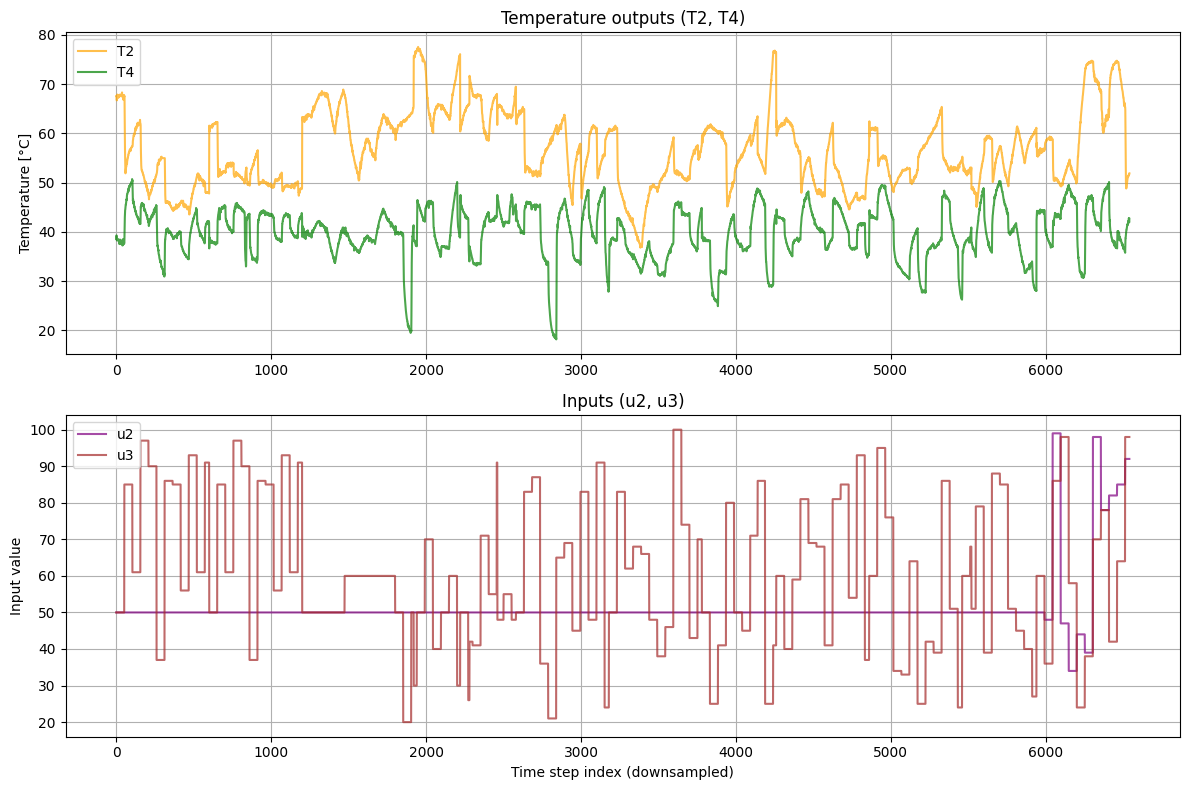

In [172]:
# Extract data for plotting (T2, T4 and u2, u3 only)
T2_data = T2_train['T2'].flatten()
T4_data = T4_train['T4'].flatten()

u2_data = u2_train['u2'].flatten()
u3_data = u3_train['u3'].flatten()

part = min(7840, len(T2_data))

plt.figure(figsize=(12, 8))

plt.subplot(2, 1, 1)
plt.plot(T2_data[:part], label='T2', alpha=0.7, color='orange')
plt.plot(T4_data[:part], label='T4', alpha=0.7, color='green')
plt.title("Temperature outputs (T2, T4)")
plt.ylabel("Temperature [°C]")
plt.legend()
plt.grid(True)

plt.subplot(2, 1, 2)
plt.plot(u2_data[:part], label='u2', alpha=0.7, color='purple')
plt.plot(u3_data[:part], label='u3', alpha=0.7, color='brown')
plt.title("Inputs (u2, u3)")
plt.xlabel("Time step index (downsampled)")
plt.ylabel("Input value")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


In [173]:
nsteps = 60   # number of prediction horizon steps in the loss function
bs = 80      # minibatching batch size

In [174]:
scaler = StandardScaler()
scaler.fit(train['Y'])  
joblib.dump(scaler, '../data/scaler.pkl')

scalerU = StandardScaler()
scalerU.fit(train['U'])
joblib.dump(scalerU, '../data/scalerU.pkl')


['../data/scalerU.pkl']

In [175]:
train_loader, dev_loader, test_data, train_data = get_data(train, test, test, nsteps, bs, scaler, scalerU)

## Creating the model


In [176]:
# model parameters
nz = 8
ny = train['Y'].shape[1]
nu = train['U'].shape[1]

# cons = 1
# layers = [8*cons, 8*cons, 8*cons]
# layers_dec  = [8*cons]

cons = 5
layers = [4*cons,8*cons,16*cons]
cons = 1
layers_dec  = [16*cons, 8*cons,4*cons]
# layers = [60, 60, 60]
# layers_dec = [60, 60, 60]

# layers = []

matrix_C = False

In [177]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class mELU(nn.Module):
    def __init__(self, alpha=1.0):
        super().__init__()
        self.alpha = alpha

    def forward(self, x):
        return -F.elu(-x, alpha=self.alpha)

In [178]:
# instantiate output encoder neural net f_y
f_y = blocks.MLP(
    ny,
    nz,
    bias=True,
    linear_map=torch.nn.Linear,
    nonlin=torch.nn.ELU,
    hsizes=layers,
)
# initial condition encoder
encode_Y0 = Node(f_y, ['Y0'], ['x'], name='encoder_Y0')
# observed trajectory encoder
encode_Y = Node(f_y, ['Y'], ['x_latent'], name='encoder_Y')

In [179]:
# instantiate input encoder net f_u, representing the B matrix in the linear system
f_u = torch.nn.Linear(nu, nz, bias=False)
# initial condition encoder
encode_U = Node(f_u, ['U'], ['u_latent'], name='encoder_U')

In [180]:
# instantiate state decoder neural net f_y_inv
if not matrix_C:
    f_y_inv = blocks.MLP(nz, ny, bias=True,
                    linear_map=torch.nn.Linear,
                    nonlin=torch.nn.ELU,
                    hsizes=layers_dec)
elif matrix_C:
    f_y_inv = torch.nn.Linear(nz, ny, bias=False)
else:
    raise ValueError('matrix_C must be boolean')

# predicted trajectory decoder
decode_y = Node(f_y_inv, ['x'], ['yhat'], name='decoder_y')

In [181]:
# representing matrix A in the linear system
K = torch.nn.Linear(nz, nz, bias=False)

In [182]:
# symbolic Koopman model with control inputs
Koopman = Node(helper.PredictionWControl(K), ['x', 'u_latent'], ['x'], name='K')

# latent Koopmann rollout
dynamics_model = System([Koopman], name='Koopman', nsteps=nsteps)

In [183]:
# put all nodes of the Koopman model together in a list of nodes
nodes = [encode_Y0, encode_Y, encode_U, dynamics_model, decode_y]

### Define Koopman system identification loss function terms

In [184]:
# variables
Y = variable("Y")  # observed
yhat = variable('yhat')  # predicted output
x_latent = variable('x_latent')  # encoded output trajectory in the latent space
u_latent = variable('u_latent')  # encoded input trajectory in the latent space
x = variable('x')  # Koopman latent space trajectory

xu_latent = x_latent + u_latent  # latent state trajectory

# output trajectory tracking loss
y_loss = 10. * (yhat[:, 1:-1, :] == Y[:, 1:, :]) ^ 2
y_loss.name = "y_loss"

# one-step tracking loss
onestep_loss = 1.*(yhat[:, 1, :] == Y[:, 1, :])^2
onestep_loss.name = "onestep_loss"

# reconstruction loss
reconstruction_loss = 1 * (yhat[:, 0, :] == Y[:, 0, :])^2
reconstruction_loss.name = "reconstruction_loss"

# latent trajectory tracking loss
x_loss = 10. * (x[:, 1:-1, :] == xu_latent[:, 1:, :]) ^ 2
x_loss.name = "x_loss"

### Construct System learning problem

In [185]:
# aggregate list of objective terms and constraints
objectives = [y_loss, x_loss, onestep_loss, reconstruction_loss]

# create constrained optimization loss
loss = PenaltyLoss(objectives, constraints=[])

# construct constrained optimization problem
problem = Problem(nodes, loss)

In [186]:
problem.nodes

ModuleList(
  (0): encoder_Y0(Y0) -> x
  (1): encoder_Y(Y) -> x_latent
  (2): encoder_U(U) -> u_latent
  (3): System(
    (nodes): ModuleList(
      (0): K(x, u_latent) -> x
    )
  )
  (4): decoder_y(x) -> yhat
)

### Solve the problem

In [187]:
from neuromancer.trainer import Callback

class PrintCallback(Callback):
    def end_eval(self, trainer, output):
        if trainer.current_epoch % trainer.epoch_verbose == 0:
            train_loss = output.get('mean_train_loss', output.get('train_loss', 'N/A'))
            dev_loss = output.get('mean_dev_loss', output.get('dev_loss', 'N/A'))
            print(f"epoch: {trainer.current_epoch}  "
                  f"train_loss: {train_loss}  "
                  f"dev_loss: {dev_loss}")

optimizer = torch.optim.Adam(problem.parameters(), lr=0.001, weight_decay=1e-4)

trainer = Trainer(
    problem,
    train_loader,
    dev_loader,
    test_data,
    optimizer,
    callback=PrintCallback(),
    patience=300,
    warmup=100,
    epochs=4000,
    eval_metric="dev_loss",
    train_metric="train_loss",
    dev_metric="dev_loss",
    test_metric="dev_loss",
)


In [188]:
# train

best_model = trainer.train()
problem.load_state_dict(best_model)


epoch: 0  train_loss: 15.612653732299805
epoch: 0  train_loss: 15.612653732299805  dev_loss: 15.324152946472168
epoch: 1  train_loss: 14.351037979125977
epoch: 1  train_loss: 14.351037979125977  dev_loss: 15.090824127197266
epoch: 2  train_loss: 14.332499504089355
epoch: 2  train_loss: 14.332499504089355  dev_loss: 14.889361381530762
epoch: 3  train_loss: 14.144559860229492
epoch: 3  train_loss: 14.144559860229492  dev_loss: 14.718741416931152
epoch: 4  train_loss: 15.248943328857422
epoch: 4  train_loss: 15.248943328857422  dev_loss: 14.578662872314453
epoch: 5  train_loss: 14.326192855834961
epoch: 5  train_loss: 14.326192855834961  dev_loss: 14.457393646240234
epoch: 6  train_loss: 14.800209999084473
epoch: 6  train_loss: 14.800209999084473  dev_loss: 14.350199699401855
epoch: 7  train_loss: 14.067207336425781
epoch: 7  train_loss: 14.067207336425781  dev_loss: 14.250503540039062
epoch: 8  train_loss: 13.871940612792969
epoch: 8  train_loss: 13.871940612792969  dev_loss: 14.15484523

<All keys matched successfully>

### Saving model and evaluation of the training

In [189]:
# save model
torch.save(best_model, "../data/model_C_" + str(matrix_C) + ".pth")

# pull matrices
A = K.weight.detach().numpy()
B = f_u.weight.detach().numpy()
if matrix_C:
    C = f_y_inv.weight.detach().numpy()
    
elif not matrix_C:
    # get approximate C matrix from training data
    problem.nodes[3].nsteps = train_data['Y'].shape[1]
    train_outputs = problem.step(train_data)

    Y = train_data['Y'].reshape(-1, ny).detach().numpy()
    Z = train_outputs['x'][:,:-1,:].detach().numpy().reshape(-1, nz)
    rankZ = np.linalg.matrix_rank(Z)
    if rankZ < nz:
        print('Rank deficient Z matrix, can result in bad fitted C matrix!')
        print(f'Rank of Z: {rankZ}, nz: {nz}')
    C, residuals, rank, s = np.linalg.lstsq(Z, Y, rcond=None)
    C = C.T

else:
    raise ValueError('matrix_C must be boolean')

In [190]:
from numpy.linalg import matrix_rank

# Compute the controllability matrix
n_states = A.shape[0]
controllability_matrix = np.hstack([np.linalg.matrix_power(A, i) @ B for i in range(n_states)])

# Check the rank of the controllability matrix
controllability_rank = matrix_rank(controllability_matrix)

print(f"Controllability Matrix Rank: {controllability_rank}")
print(f"System is {'controllable' if controllability_rank == n_states else 'not controllable'}")

# Compute the observability matrix
observability_matrix = np.vstack([C @ np.linalg.matrix_power(A, i) for i in range(n_states)])

# Check the rank of the observability matrix
observability_rank = matrix_rank(observability_matrix)

print(f"Observability Matrix Rank: {observability_rank}")
print(f"System is {'observable' if observability_rank == n_states else 'not observable'}")

Controllability Matrix Rank: 8
System is controllable
Observability Matrix Rank: 8
System is observable


In [191]:
np.save('../data/A_C_' + str(matrix_C) + '.npy', A)
np.save('../data/B_C_' + str(matrix_C) + '.npy', B)
np.save('../data/C_C_' + str(matrix_C) + '.npy', C)

In [192]:
# update the rollout length based on the test data
problem.nodes[3].nsteps = test_data['Y'].shape[1]

In [193]:
# do the prediction
test_outputs = problem.step(test_data)

pred_traj = test_outputs['yhat'][:, 1:-1, :].detach().numpy().reshape(-1, ny).T
true_traj = test_data['Y'][:, 1:pred_traj.shape[1]+1, ].detach().numpy().reshape(-1, ny).T
input_traj = test_data['U'].detach().numpy().reshape(-1, nu).T
pred_x = test_outputs['x'][:, 1:-1, :].detach().numpy().reshape(-1, nz).T

In [194]:
pred_traj_C = np.dot(C, pred_x)

In [195]:
x_mean = np.mean(pred_x, axis=1, keepdims=True)
x_med = np.median(pred_x, axis=1, keepdims=True)

In [196]:
def get_y_from_x(problem, x: np.ndarray) -> np.ndarray:
    y = problem.nodes[4]({"x": torch.from_numpy(x.T).float()})
    return y["yhat"].detach().numpy().reshape(1, -1)

In [197]:
J = helper.evaluate_jacobian(
    problem.nodes[4],
    torch.from_numpy(x_mean[:,0]).float(),
)
# Get all latent states from training data
x_train = train_outputs['x'].detach().numpy().reshape(-1, nz)

# Evaluate Jacobian for each latent state
J_all = np.stack([
    helper.evaluate_jacobian(problem.nodes[4], torch.from_numpy(xi).float())
    for xi in x_train
])

bias_all = np.stack([
    get_y_from_x(problem, xi.reshape(-1,1))
    for xi in x_train
])

# Compute mean Jacobian
J_mean = np.mean(J_all, axis=0)
print("Mean Jacobian J_mean:\n", J_mean) # mean bias?

bias_mean = np.mean(bias_all, axis=0)
print("Mean Bias:\n", bias_mean)


pred_traj_J = np.dot(J_mean, pred_x - x_mean) #+ bias_mean.T

Mean Jacobian J_mean:
 [[ 0.54319537  1.1108068  -0.06258632  0.24081634  1.1163244   0.2902069
   0.47277707  1.1611227 ]
 [ 1.257262   -0.5420506  -1.0540372  -0.14385346 -0.5050263   0.2396572
  -0.8898578   0.29466173]
 [ 0.5353421   1.095635   -0.05368322  0.23418099  1.0929767   0.27311176
   0.45277324  1.1323942 ]
 [ 0.7639639   0.87228686 -0.5864486  -0.0617742   1.1750013   0.77892375
   0.63310915  1.4746932 ]]
Mean Bias:
 [[0.1812428  0.31381342 0.18124537 0.2603982 ]]


In [198]:
x_lin = np.zeros((nz,1))
J = helper.evaluate_jacobian(
    problem.nodes[4],
    torch.from_numpy(x_lin[:,0]).float(),
)

bias = get_y_from_x(problem, x_lin)
pred_traj_J = np.dot(J, pred_x - x_lin) + bias.T

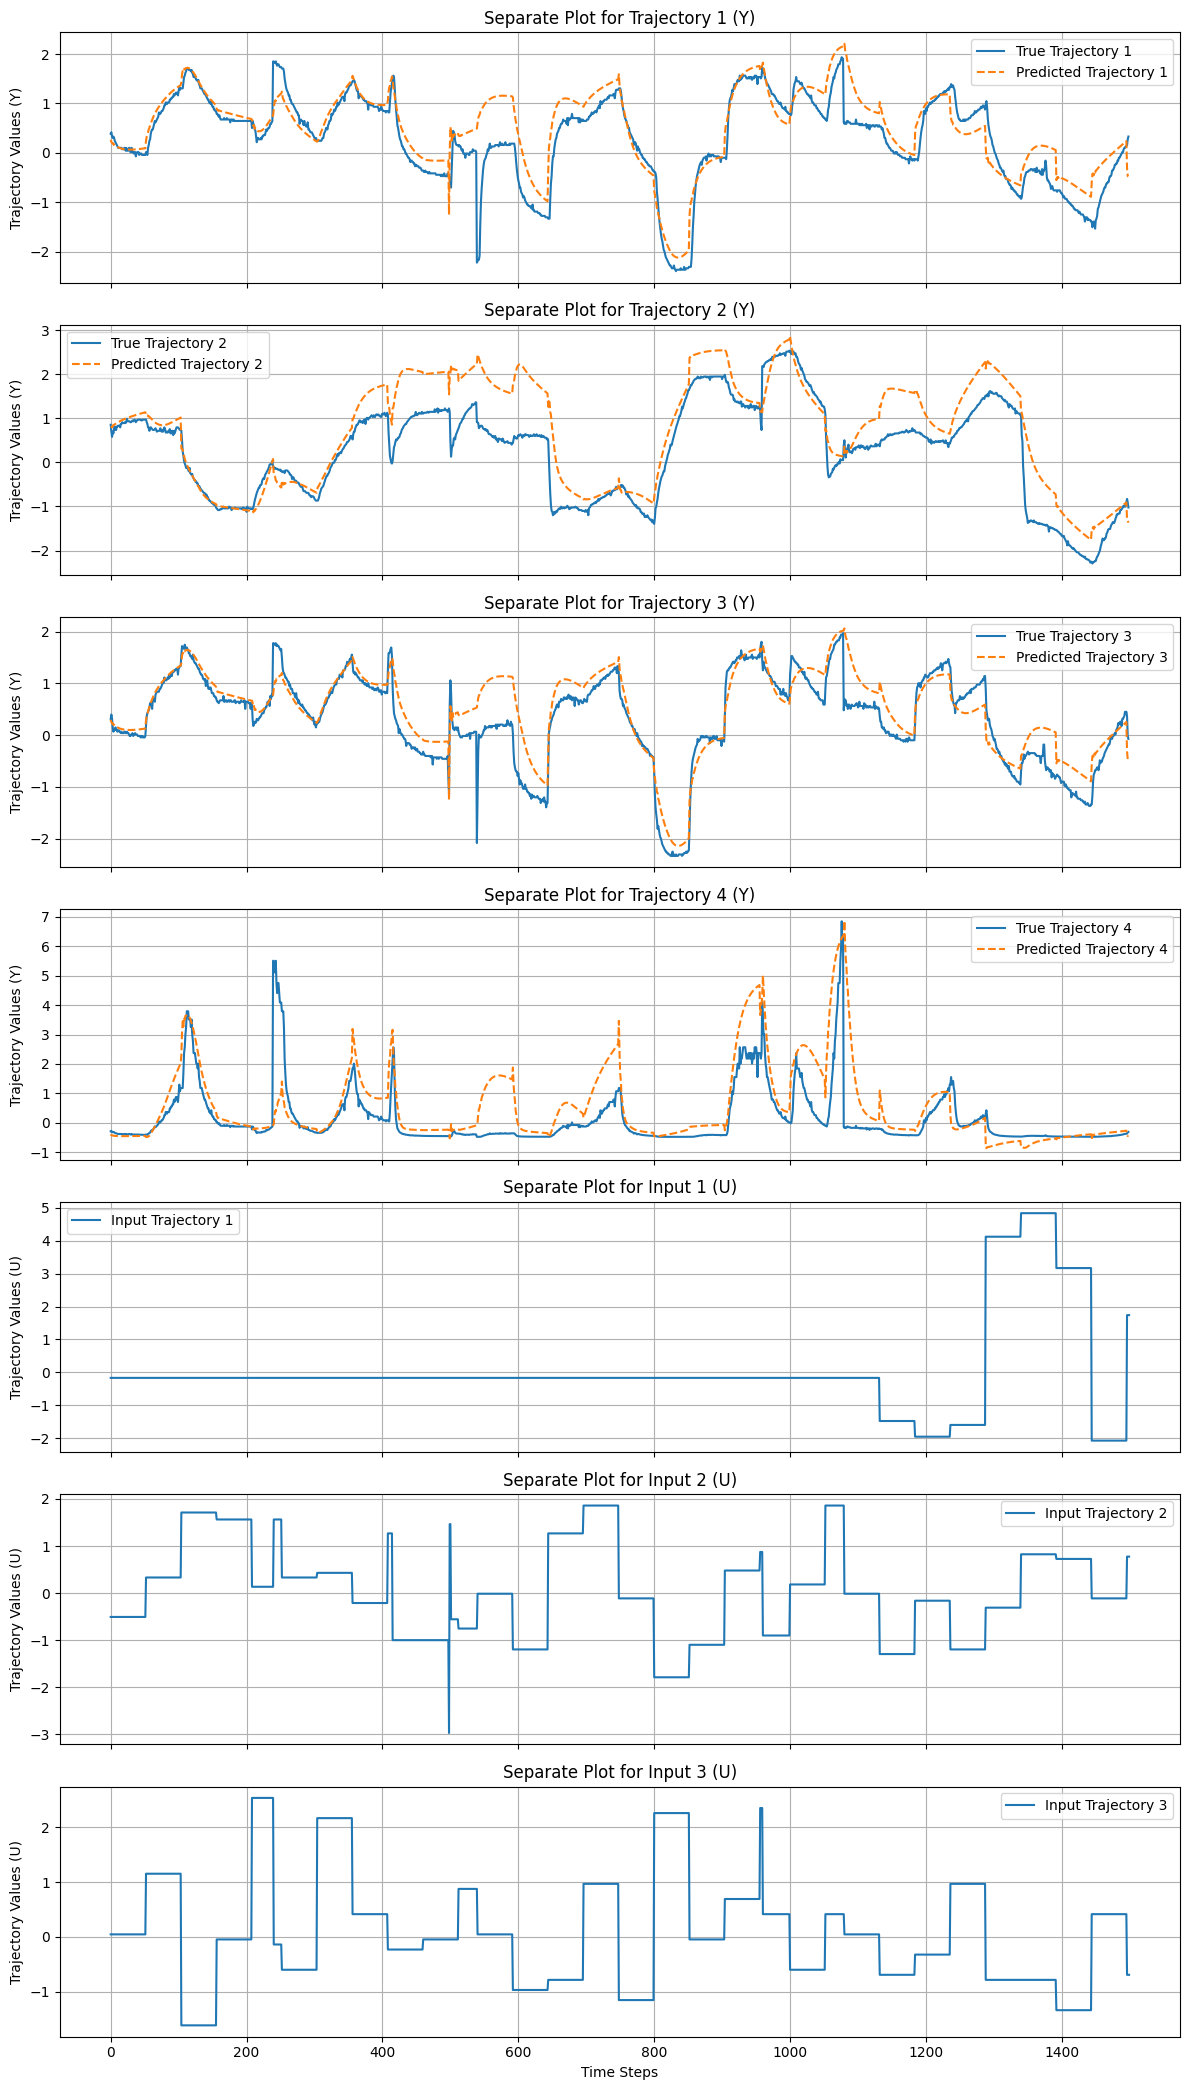

In [199]:
fig, axs = plt.subplots(ny + nu, 1, figsize=(12, 3 * (ny + nu)), sharex=True)

# Separate plots for each vector in Y
for i in range(ny):
    axs[i].plot(true_traj[i], label=f'True Trajectory {i + 1}', linestyle='-')
    axs[i].plot(pred_traj[i], label=f'Predicted Trajectory {i + 1}', linestyle='--')
    # axs[i].plot(pred_traj_C[i], label=f'Predicted Trajectory {i + 1} C', linestyle='--')
    #axs[i].plot(pred_traj_J[i], label=f'Predicted Trajectory {i + 1} J', linestyle='--')
    axs[i].set_title(f'Separate Plot for Trajectory {i + 1} (Y)')
    axs[i].legend()
    axs[i].grid()

# Separate plots for each vector in U
for i in range(nu):
    axs[ny + i].plot(input_traj[i], label=f'Input Trajectory {i + 1}', linestyle='-')
    axs[ny + i].set_title(f'Separate Plot for Input {i + 1} (U)')
    axs[ny + i].legend()
    axs[ny + i].grid()

# Add labels
axs[-1].set_xlabel('Time Steps')
for i in range(ny):
    axs[i].set_ylabel('Trajectory Values (Y)')
for i in range(nu):
    axs[ny + i].set_ylabel('Trajectory Values (U)')

plt.tight_layout()
plt.show()


In [200]:
# calculate MAE of predicted trajectories
mae_pred = np.mean(np.abs(true_traj[:, :] - pred_traj[:, :]), axis=1)
mae_pred_C = np.mean(np.abs(true_traj[:, :] - pred_traj_C[:, :]), axis=1)
mae_pred_J = np.mean(np.abs(true_traj[:, :] - pred_traj_J[:, :]), axis=1)
print(f'MAE of predicted trajectory: {sum(mae_pred)}')
print(f'MAE of predicted trajectory C: {sum(mae_pred_C)}')
print(f'MAE of predicted trajectory J: {sum(mae_pred_J)}')
# 1.16

MAE of predicted trajectory: 1.6941325664520264
MAE of predicted trajectory C: 1.6986340284347534
MAE of predicted trajectory J: 2.6309495415369133


In [201]:
# Calculate variance of mismatch (error) between test data and predicted data
var_error_pred = np.var(true_traj - pred_traj, axis=1)
var_error_pred_C = np.var(true_traj - pred_traj_C, axis=1)
var_error_pred_J = np.var(true_traj - pred_traj_J, axis=1)

print(f'Variance of mismatch (True - Predicted): {var_error_pred}')
print(f'Variance of mismatch (True - Predicted C): {var_error_pred_C}')
print(f'Variance of mismatch (True - Predicted J): {var_error_pred_J}')



Variance of mismatch (True - Predicted): [0.15764527 0.22250782 0.11922099 0.82772654]
Variance of mismatch (True - Predicted C): [0.27138367 0.23758273 0.24795358 0.63716894]
Variance of mismatch (True - Predicted J): [0.40427967 0.89449626 0.35248124 0.70814985]


In [202]:
# Calculate mean squared error (MSE) of all test predictions
mse_pred = np.mean((true_traj - pred_traj) ** 2)
mse_pred_C = np.mean((true_traj - pred_traj_C) ** 2)
mse_pred_J = np.mean((true_traj - pred_traj_J) ** 2)

print(f'MSE of predicted trajectory: {mse_pred}')
print(f'MSE of predicted trajectory C: {mse_pred_C}')
print(f'MSE of predicted trajectory J: {mse_pred_J}')


MSE of predicted trajectory: 0.4450778365135193
MSE of predicted trajectory C: 0.3548365831375122
MSE of predicted trajectory J: 0.7686756195555869


In [203]:
# Define lower and upper bounds for true_traj values
lower_bound = -0.50
upper_bound = 0.50

# Create mask for values within the specified range
mask = (true_traj >= lower_bound) & (true_traj <= upper_bound)

# Compute MAE only for masked values
mae_pred_masked = [np.mean(np.abs(true_traj[i][mask[i]] - pred_traj[i][mask[i]])) for i in range(true_traj.shape[0])]
mae_pred_C_masked = [np.mean(np.abs(true_traj[i][mask[i]] - pred_traj_C[i][mask[i]])) for i in range(true_traj.shape[0])]
mae_pred_J_masked = [np.mean(np.abs(true_traj[i][mask[i]] - pred_traj_J[i][mask[i]])) for i in range(true_traj.shape[0])]

print(f'Masked MAE of predicted trajectory: {mae_pred_masked}')
print(f'Masked MAE of predicted trajectory C: {mae_pred_C_masked}')
print(f'Masked MAE of predicted trajectory J: {mae_pred_J_masked}')

Masked MAE of predicted trajectory: [np.float32(0.3168318), np.float32(0.3844915), np.float32(0.30350313), np.float32(0.43248457)]
Masked MAE of predicted trajectory C: [np.float32(0.28190538), np.float32(0.20315106), np.float32(0.29297343), np.float32(0.33503702)]
Masked MAE of predicted trajectory J: [np.float64(0.5197461479441675), np.float64(0.6626806525147655), np.float64(0.5238287376936163), np.float64(0.3444944784426963)]


In [204]:
J_mean

array([[ 0.54319537,  1.1108068 , -0.06258632,  0.24081634,  1.1163244 ,
         0.2902069 ,  0.47277707,  1.1611227 ],
       [ 1.257262  , -0.5420506 , -1.0540372 , -0.14385346, -0.5050263 ,
         0.2396572 , -0.8898578 ,  0.29466173],
       [ 0.5353421 ,  1.095635  , -0.05368322,  0.23418099,  1.0929767 ,
         0.27311176,  0.45277324,  1.1323942 ],
       [ 0.7639639 ,  0.87228686, -0.5864486 , -0.0617742 ,  1.1750013 ,
         0.77892375,  0.63310915,  1.4746932 ]], dtype=float32)

In [205]:
C

array([[ 0.12737027,  1.1058973 , -0.54107624,  0.3711797 ,  0.7872773 ,
         0.5342028 ,  1.0653504 ,  0.8969153 ],
       [ 0.40659943, -0.46004555, -1.1377482 , -0.5352839 , -0.8669313 ,
         1.1509043 , -0.2508121 ,  0.11809099],
       [ 1.1777912 ,  1.2791197 ,  0.12005569,  1.987219  ,  1.5963173 ,
        -2.2599144 , -0.54342633,  0.5702482 ],
       [ 0.1520354 ,  0.967878  , -1.2435182 , -0.02872077,  0.37015304,
         0.34810886,  1.1907368 , -0.03175971]], dtype=float32)

In [206]:
# mse C-J
mse_C_J = np.mean((C - J_mean) ** 2)
print("Mean Squared Error between C and J_mean:\n", mse_C_J)
# mse C-J
mse_C_J = np.mean((C - J) ** 2)
print("Mean Squared Error between C and J:\n", mse_C_J)

Mean Squared Error between C and J_mean:
 0.5955314
Mean Squared Error between C and J:
 0.7064203


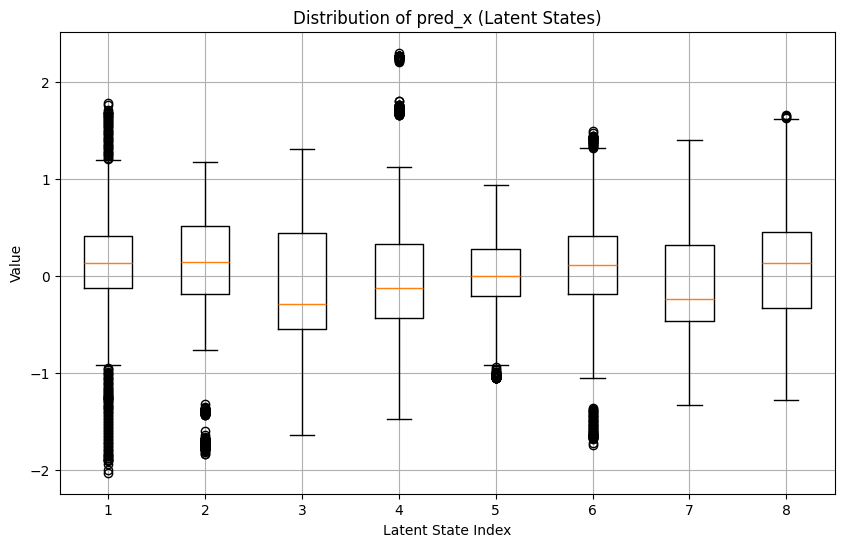

In [207]:
plt.figure(figsize=(10, 6))
plt.boxplot(pred_x.T)
plt.title('Distribution of pred_x (Latent States)')
plt.xlabel('Latent State Index')
plt.ylabel('Value')
plt.grid(True)
plt.show()

## Open-loop simulation with zero inputs


In [208]:
# Set up open-loop simulation parameters
n_sim_steps = 500

# Use mean of training data as initial condition (in original scale)
Y0_mean = np.mean(train['Y'], axis=0).reshape(1, 1, ny)

# Scale the initial condition
Y0_scaled = scaler.transform(Y0_mean.reshape(1, -1)).reshape(1, 1, ny)
Y0_tensor = torch.tensor(Y0_scaled, dtype=torch.float32)

# Create zero inputs for all simulation steps (in original scale)
U_scaled = np.zeros((1, n_sim_steps, nu))
U_tensor = torch.tensor(U_scaled, dtype=torch.float32)

# Create dummy Y vector as zeros for all simulation steps
Y_dummy_scaled = np.zeros((1, n_sim_steps, ny))
Y_dummy_tensor = torch.tensor(Y_dummy_scaled, dtype=torch.float32)

# Create simulation data dictionary, adding dummy Y
sim_data = {
    'Y0': Y0_tensor,
    'U': U_tensor,
    'Y': Y_dummy_tensor
}

print(f"Initial condition (scaled): {Y0_scaled.flatten()}")
print(f"Input shape: {U_tensor.shape}")
print(f"Dummy Y shape: {Y_dummy_tensor.shape}")
print(f"Simulation will run for {n_sim_steps} steps")


Initial condition (scaled): [0. 0. 0. 0.]
Input shape: torch.Size([1, 500, 3])
Dummy Y shape: torch.Size([1, 500, 4])
Simulation will run for 500 steps


In [209]:
# Update the rollout length for simulation
problem.nodes[3].nsteps = n_sim_steps

# Run the open-loop simulation
sim_outputs = problem.step(sim_data)

# Extract predicted outputs
sim_yhat = sim_outputs['yhat'][:, 1:-1, :].detach().numpy().reshape(-1, ny)

# Unscale the outputs to original scale
sim_yhat_unscaled = scaler.inverse_transform(sim_yhat)

# Extract latent states
sim_x = sim_outputs['x'][:, 1:-1, :].detach().numpy().reshape(-1, nz)

print(f"Simulation completed!")
print(f"Output shape: {sim_yhat_unscaled.shape}")
print(f"Latent state shape: {sim_x.shape}")


Simulation completed!
Output shape: (499, 4)
Latent state shape: (499, 8)


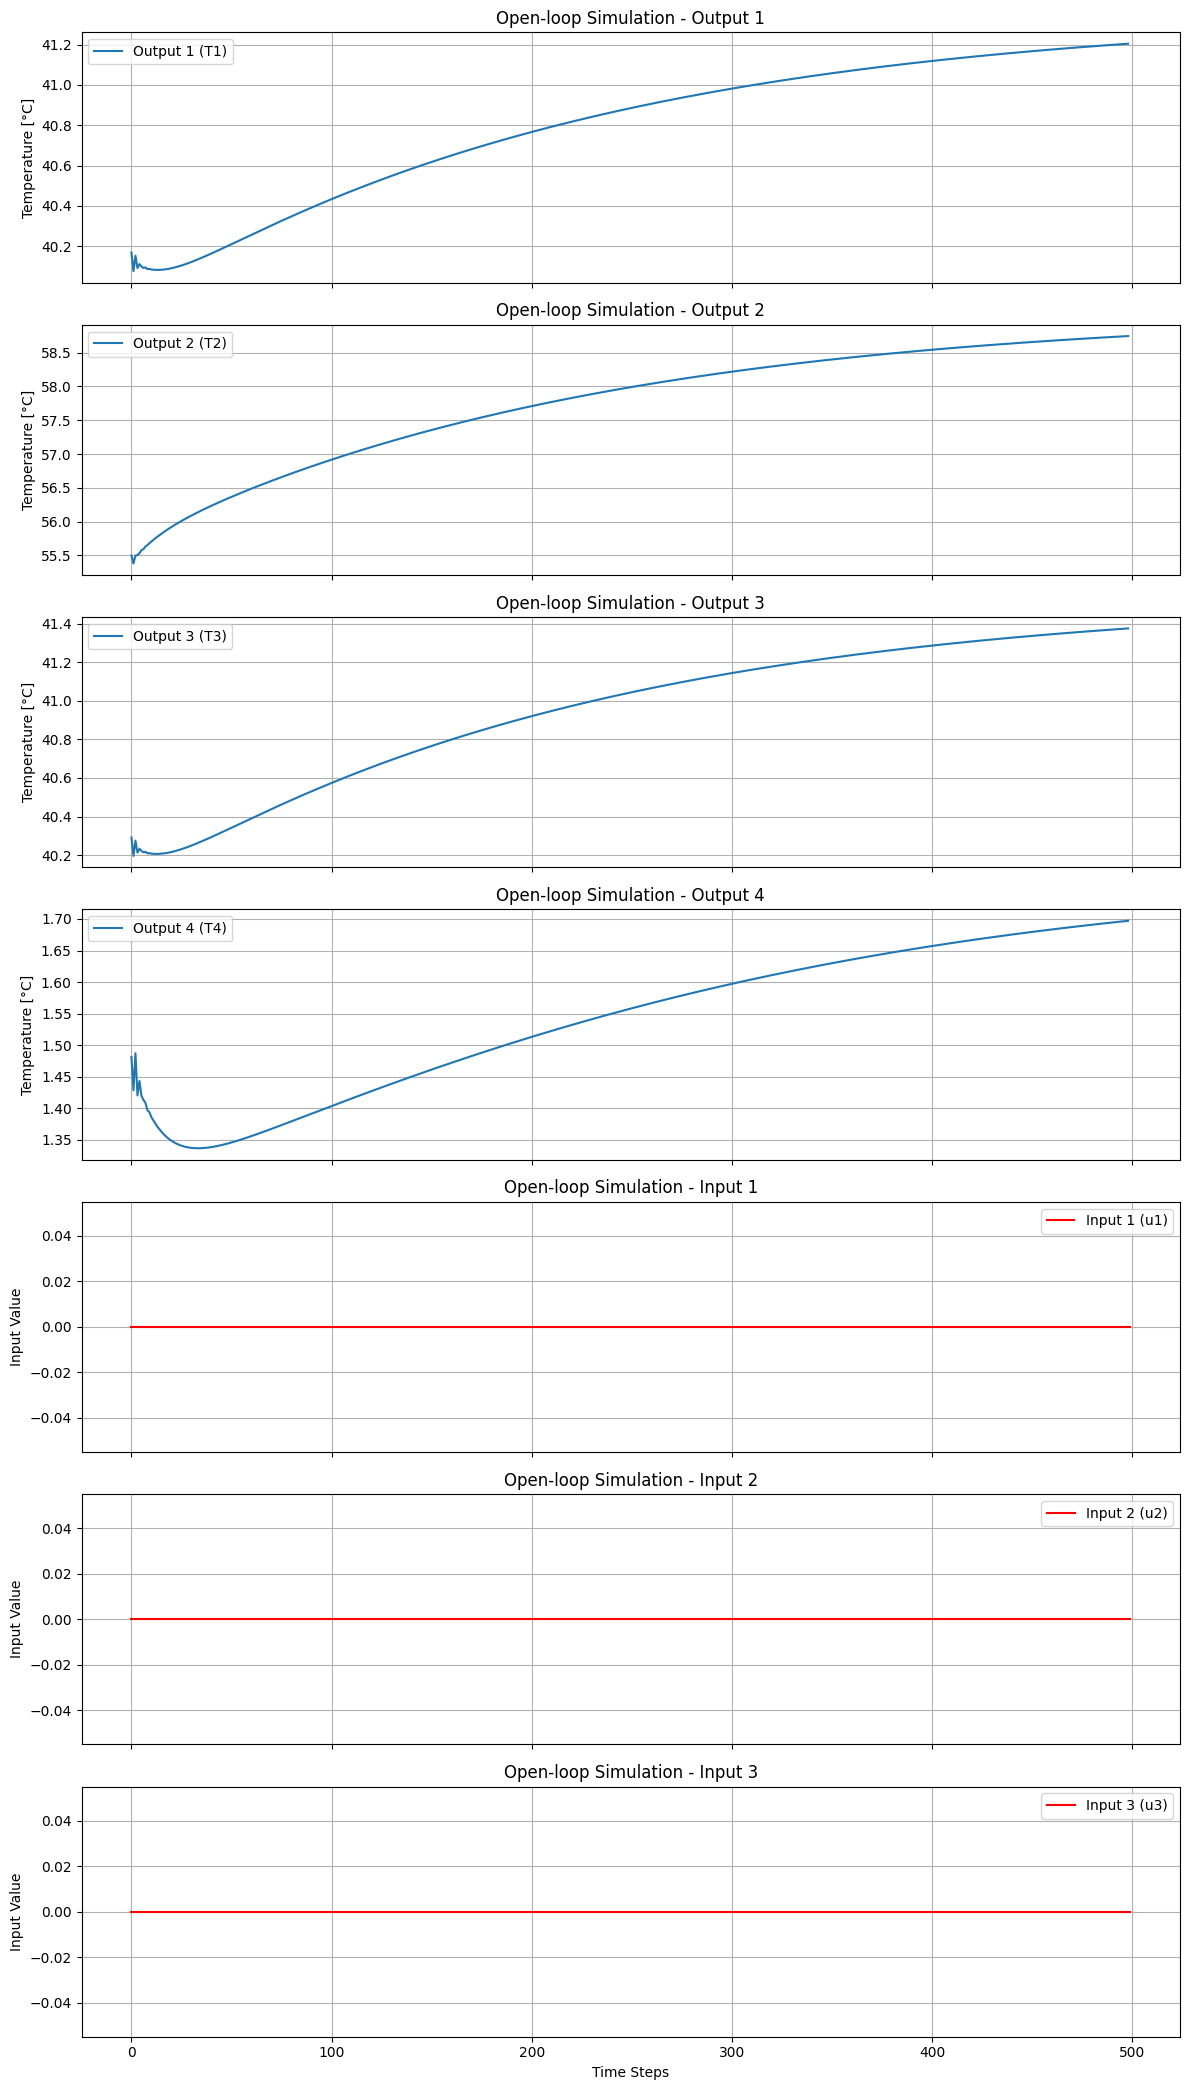


Simulation Statistics:
Final output values: [41.204617  58.746307  41.37638    1.6970757]
Output range: [[40.076813  55.38004   40.195602   1.3369209], [41.204617  58.746307  41.37638    1.6970757]]
Output mean: [40.786335  57.73202   40.940865   1.5382205]
Output std: [0.34641525 0.87023544 0.3609768  0.11489445]


In [210]:
# Plot the open-loop simulation results
fig, axs = plt.subplots(ny + nu, 1, figsize=(12, 3 * (ny + nu)), sharex=True)

# Plot outputs
for i in range(ny):
    axs[i].plot(sim_yhat_unscaled[:, i], label=f'Output {i + 1} (T{i+1 if i < 3 else i+1})', linewidth=1.5)
    axs[i].set_title(f'Open-loop Simulation - Output {i + 1}')
    axs[i].set_ylabel('Temperature [°C]')
    axs[i].legend()
    axs[i].grid(True)

# Plot inputs (zeros)
for i in range(nu):
    axs[ny + i].plot(U_scaled[0, :, i], label=f'Input {i + 1} (u{i+1})', linewidth=1.5, color='red')
    axs[ny + i].set_title(f'Open-loop Simulation - Input {i + 1}')
    axs[ny + i].set_ylabel('Input Value')
    axs[ny + i].legend()
    axs[ny + i].grid(True)

# Add x-axis label to the last subplot
axs[-1].set_xlabel('Time Steps')

plt.tight_layout()
plt.show()

# Print some statistics
print("\nSimulation Statistics:")
print(f"Final output values: {sim_yhat_unscaled[-1, :]}")
print(f"Output range: [{sim_yhat_unscaled.min(axis=0)}, {sim_yhat_unscaled.max(axis=0)}]")
print(f"Output mean: {sim_yhat_unscaled.mean(axis=0)}")
print(f"Output std: {sim_yhat_unscaled.std(axis=0)}")
